In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
from datasets import load_dataset
import re
import random
from tensorflow import keras
import matplotlib.pyplot as plt

In [2]:
# Reproducibility: set global seeds
import os
import random
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass


In [4]:
df = pd.read_csv("ranking_dataset.csv")
print(df.head())

   val_0  val_1  val_2  val_3  val_4  val_5  val_6  val_7  val_8  val_9  \
0    542     67    876    414     26    335    620    924    950    113   
1    378     14    210    954    231    572    315    295    567    706   
2    749    876     73    111    899    213    541    769    287    219   
3    372    880    475    329    733    564    739    376    632     10   
4    186    822    577    519    707    123    143    294    693    677   

   rank_0  rank_1  rank_2  rank_3  rank_4  rank_5  rank_6  rank_7  rank_8  \
0       5       1       7       4       0       3       6       8       9   
1       5       0       1       9       2       7       4       3       6   
2       6       8       0       1       9       2       5       7       4   
3       2       9       4       1       7       5       8       3       6   
4       2       9       5       4       8       0       1       3       7   

   rank_9  
0       2  
1       8  
2       3  
3       0  
4       6  


In [ ]:
len(df)

10000

In [5]:
pairs = []
for i in range(len(df)):
  vals = []
  ranks = []
  for j in range(10):
    vals.append(df.iloc[i, j])
  for k in range(10, 20):
    ranks.append(df.iloc[i, k])
  pairs.append((vals, ranks))

print(pairs[0])

([np.int64(542), np.int64(67), np.int64(876), np.int64(414), np.int64(26), np.int64(335), np.int64(620), np.int64(924), np.int64(950), np.int64(113)], [np.int64(5), np.int64(1), np.int64(7), np.int64(4), np.int64(0), np.int64(3), np.int64(6), np.int64(8), np.int64(9), np.int64(2)])


In [6]:
train = pairs[:7000]
eval = pairs[7000:8500]
test = pairs[8500:]

In [7]:
def batches(pairs, batch_size):
    #random.shuffle(pairs)
    for i in range(0, len(pairs) - batch_size + 1, batch_size):

        batch = pairs[i: i + batch_size]

        inputs = []
        targets = []

        for i in batch:
            inputs.append(i[0])
            targets.append(i[1])

        yield tf.constant(inputs, dtype=tf.int32), tf.constant(targets, dtype=tf.int32)



#[([],[]),([],[]),([],[])]
#([],[])

In [ ]:
#X, y = batches(pairs, 5)
#X = tf.expand_dims(X, -1)

print(type(batches(pairs, 5)))
#print(len(batches(pairs, 5)))

#print(X[0])

<class 'generator'>


In [ ]:
%pip install evaluate

MLP

In [8]:
batchsize = 100
d_model = 256
EPOCHS = 30
loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=False)
optimizer = keras.optimizers.Adam(learning_rate=1e-3)

In [9]:
mlp = keras.Sequential([keras.layers.Input(shape=(10,1)),
keras.layers.Dense(d_model, activation= 'relu'),
keras.layers.Dense(d_model, activation= 'relu'),
keras.layers.Dropout(0.3),
keras.layers.Dense(10, activation='softmax')])


In [ ]:
import evaluate

losstrack = []
acctrack = []

for epoch in range(1, EPOCHS + 1):

    accuracy_metric = evaluate.load("accuracy")

    #training

    train_loss, steps = 0, 0
    for Xtrain, ytrain in batches(train, batchsize):
        with tf.GradientTape() as tape:
            predictions = mlp(Xtrain, training=True)
            loss = loss_fn(ytrain, predictions)
        grads = tape.gradient(loss, mlp.trainable_variables)
        optimizer.apply_gradients(zip(grads, mlp.trainable_variables))
        train_loss += loss.numpy()
        steps += 1

    losstrack.append(train_loss/steps)

    #validation

    for Xval, yval in batches(eval, batchsize):
        predictions = mlp(Xval, training=False)
        preds = tf.argmax(predictions, axis=-1).numpy().flatten()
        targets = yval.numpy().flatten()
        accuracy_metric.add_batch(predictions=preds, references=targets)

    val_acc = accuracy_metric.compute()["accuracy"] * 100
    acctrack.append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS}  Loss: {train_loss/steps:.4f}  Val Acc: {val_acc:.2f}%")




In [13]:
# Save MLP weights
import os
os.makedirs('./checkpoints/mlp', exist_ok=True)
mlp.save_weights('./checkpoints/mlp/mlp_weights.weights.h5')




In [14]:
mlp.load_weights('./checkpoints/mlp/mlp_weights.weights.h5')

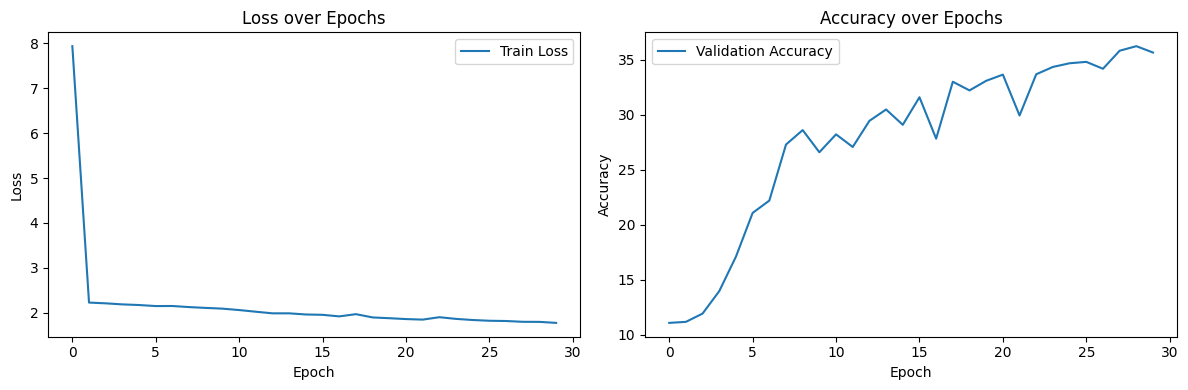

In [15]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losstrack, label='Train Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(acctrack, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
#testing

for Xtest, ytest in batches(test, batchsize):
        predictions = mlp(Xtest, training=False)
        preds = tf.argmax(predictions, axis=-1).numpy().flatten()
        targets = ytest.numpy().flatten()
        accuracy_metric.add_batch(predictions=preds, references=targets)

test_acc = accuracy_metric.compute()["accuracy"] * 100
print(f"\nTest Acc: {test_acc:.2f}%")


Test Acc: 36.29%


RNN

In [ ]:
batchsize = 100
d_model = 128
EPOCHS = 15
loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = keras.optimizers.Adam(learning_rate=1e-3)

In [ ]:
rnn = keras.Sequential([keras.layers.Input(shape=(10,1)),
keras.layers.Dense(d_model),
keras.layers.SimpleRNN(d_model, return_sequences=True),
keras.layers.Dropout(0.4),
keras.layers.Dense(10)])


In [ ]:
import evaluate

losstrack = []
acctrack = []

for epoch in range(1, EPOCHS + 1):

    accuracy_metric = evaluate.load("accuracy")

    #training

    train_loss, steps = 0, 0
    for Xtrain, ytrain in batches(train, batchsize):
        with tf.GradientTape() as tape:
            predictions = rnn(Xtrain, training=True)
            loss = loss_fn(ytrain, predictions)
        grads = tape.gradient(loss, rnn.trainable_variables)
        optimizer.apply_gradients(zip(grads, rnn.trainable_variables))
        train_loss += loss.numpy()
        steps += 1

    losstrack.append(train_loss/steps)

    #validation

    for Xval, yval in batches(eval, batchsize):
        predictions = rnn(Xval, training=False)
        preds = tf.argmax(predictions, axis=-1).numpy().flatten()
        targets = yval.numpy().flatten()
        accuracy_metric.add_batch(predictions=preds, references=targets)

    val_acc = accuracy_metric.compute()["accuracy"] * 100
    acctrack.append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS}  Loss: {train_loss/steps:.4f}  Val Acc: {val_acc:.2f}%")




In [ ]:
# Save RNN weights
import os
os.makedirs('./checkpoints/rnn', exist_ok=True)
rnn.save_weights('./checkpoints/rnn/rnn_weights')


In [ ]:
rnn.load_weights('./checkpoints/rnn/rnn_weights')

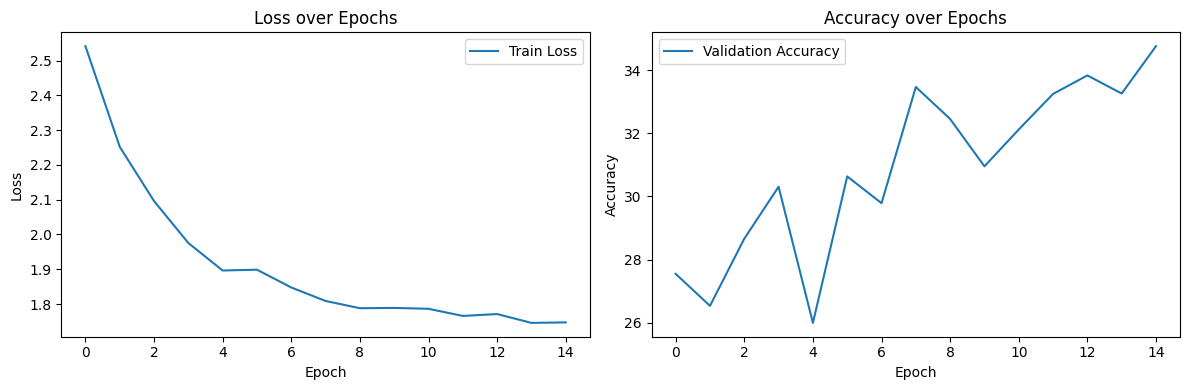

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losstrack, label='Train Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(acctrack, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
#testing

for Xtest, ytest in batches(test, batchsize):
        predictions = rnn(Xtest, training=False)
        preds = tf.argmax(predictions, axis=-1).numpy().flatten()
        targets = ytest.numpy().flatten()
        accuracy_metric.add_batch(predictions=preds, references=targets)

test_acc = accuracy_metric.compute()["accuracy"] * 100
print(f"\nTest Acc: {test_acc:.2f}%")


Test Acc: 35.01%


LSTM

In [ ]:
batchsize = 100
d_model = 128
EPOCHS = 25
loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=False)
optimizer = keras.optimizers.Adam(learning_rate=0.0001)

In [ ]:
lstm = keras.Sequential([keras.layers.Input(shape=(10,1)),
keras.layers.Dense(d_model),
keras.layers.LSTM(d_model, return_sequences=True),
keras.layers.Dropout(0.3),
keras.layers.LSTM(d_model, return_sequences=True),
keras.layers.Dropout(0.4),
keras.layers.Dense(10, activation = 'softmax')])

In [ ]:
import evaluate

losstrack = []
acctrack = []

for epoch in range(1, EPOCHS + 1):

    accuracy_metric = evaluate.load("accuracy")

    #training

    train_loss, steps = 0, 0
    for Xtrain, ytrain in batches(train, batchsize):
        with tf.GradientTape() as tape:
            predictions = lstm(Xtrain, training=True)
            loss = loss_fn(ytrain, predictions)
        grads = tape.gradient(loss, lstm.trainable_variables)
        optimizer.apply_gradients(zip(grads, lstm.trainable_variables))
        train_loss += loss.numpy()
        steps += 1

    losstrack.append(train_loss/steps)

    #validation

    for Xval, yval in batches(eval, batchsize):
        predictions = lstm(Xval, training=False)
        preds = tf.argmax(predictions, axis=-1).numpy().flatten()
        targets = yval.numpy().flatten()
        accuracy_metric.add_batch(predictions=preds, references=targets)

    val_acc = accuracy_metric.compute()["accuracy"] * 100
    acctrack.append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS}  Loss: {train_loss/steps:.4f}  Val Acc: {val_acc:.2f}%")





In [ ]:
# Save LSTM weights
import os
os.makedirs('./checkpoints/lstm', exist_ok=True)
lstm.save_weights('./checkpoints/lstm/lstm_weights')


In [ ]:
lstm.load_weights('./checkpoints/lstm/lstm_weights')

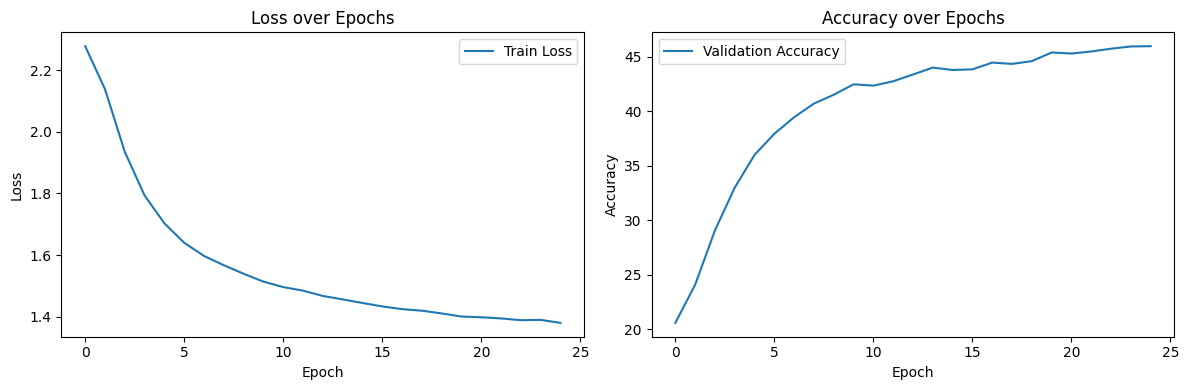

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losstrack, label='Train Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(acctrack, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
#testing

for Xtest, ytest in batches(test, batchsize):
        predictions = lstm(Xtest, training=False)
        preds = tf.argmax(predictions, axis=-1).numpy().flatten()
        targets = ytest.numpy().flatten()
        accuracy_metric.add_batch(predictions=preds, references=targets)

test_acc = accuracy_metric.compute()["accuracy"] * 100
print(f"\nTest Acc: {test_acc:.2f}%")


Test Acc: 45.72%
